# Turnover and tracking

The constraints so far shape *what* the portfolio holds. **Turnover** and **tracking** constrain
how it *moves*: how far it may drift from your current book when you rebalance, and how far it may
stray from a benchmark. Both come in two flavours in `PortfolioOptimisers.jl` — as a **constraint**
on a `JuMPOptimiser`, or as a **risk measure** you minimise directly — and the choice
between them is the difference between "respect this limit" and "make this the goal".

  - **Turnover** (`Turnover` via `tn`, or `TurnoverRiskMeasure`) penalises trading
    away from a reference weight vector.
  - **Tracking** (`TrackingError` via `tr`, or `TrackingRiskMeasure`) penalises
    deviation from a benchmark, specified either as weights (`WeightsTracking`) or as a
    benchmark return series (`ReturnsTracking` — e.g. an index).

> **When to reach for this**
>
> Reach for **turnover** when trading is costly and you rebalance often — you want the new book
> close to the old one. Reach for **tracking** when you are benchmarked: index replication
> (minimise tracking error) or enhanced indexing (seek return *subject to* a tracking-error
> budget). Use the *constraint* form when the limit is a hard mandate, the *risk-measure* form
> when staying put / hugging the benchmark is itself the objective.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Data and a benchmark

We use the S&P 500 slice, and two benchmarks: an equal-weight book (a weight vector) and the
S&P 500 index itself (a return series).

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
N = length(rd.nx)

idx = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500_idx.csv.gz")); timestamp = :Date)
index_returns = vec(values(percentchange(idx)))[(end - 251):end]

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

equal_weight = fill(1 / N, N)

20-element Vector{Float64}:
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05
 0.05

## 2. Turnover as a constraint

`Turnover` (`tn`) limits how far the weights may move from a reference book `w` — your
current holdings — so a rebalance stays cheap. We seek the maximum-ratio portfolio but anchor it
at the equal-weight book and tighten the per-name turnover budget `val`. A smaller budget keeps
the result closer to where we started.

In [3]:
turnover_vals = [0.005, 0.02, 0.1, 0.5]
turnover_res = [optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                  opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                      tn = Turnover(; w = equal_weight,
                                                                    val = v))))
                for v in turnover_vals]

drift(w) = sum(abs, w .- equal_weight)
pretty_table(DataFrame("Turnover budget" => turnover_vals,
                       "Drift from start" => drift.(getproperty.(turnover_res, :w)),
                       "Max weight" => maximum.(getproperty.(turnover_res, :w)));
             formatters = [resfmt],
             title = "Tighter turnover budget keeps the book near the reference")

Tighter turnover budget keeps the book near the reference
┌─────────────────┬──────────────────┬────────────┐
│ Turnover budget │ Drift from start │ Max weight │
│         Float64 │          Float64 │    Float64 │
├─────────────────┼──────────────────┼────────────┤
│           0.005 │           10.0 % │      5.5 % │
│            0.02 │           40.0 % │      7.0 % │
│             0.1 │        125.917 % │     15.0 % │
│             0.5 │          170.0 % │     55.0 % │
└─────────────────┴──────────────────┴────────────┘


## 3. Turnover as a risk measure

`TurnoverRiskMeasure` makes *minimising* turnover the objective rather than a side
constraint. Minimising turnover from the current book with no other pull simply returns the
current book — useful as one term in a multi-objective problem, or to measure the trading cost of
a target.

In [4]:
res_min_turnover = optimise(MeanRisk(; r = TurnoverRiskMeasure(; w = equal_weight),
                                     obj = MinimumRisk(),
                                     opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 4. Tracking a benchmark

`TrackingRiskMeasure` minimises the tracking error to a benchmark. With a
`WeightsTracking` benchmark it reproduces that book exactly; with a
`ReturnsTracking` benchmark — here the S&P 500 index return series — it builds the
*replicating* portfolio from our 20 assets that best tracks the index.

In [5]:
res_replicate_ew = optimise(MeanRisk(;
                                     r = TrackingRiskMeasure(;
                                                             tr = WeightsTracking(;
                                                                                  w = equal_weight)),
                                     obj = MinimumRisk(),
                                     opt = JuMPOptimiser(; pe = pr, slv = slv)))
res_replicate_idx = optimise(MeanRisk(;
                                      r = TrackingRiskMeasure(;
                                                              tr = ReturnsTracking(;
                                                                                   w = index_returns)),
                                      obj = MinimumRisk(),
                                      opt = JuMPOptimiser(; pe = pr, slv = slv)))

pretty_table(DataFrame("Asset" => rd.nx, "Replicate EW" => res_replicate_ew.w,
                       "Replicate index" => res_replicate_idx.w); formatters = [resfmt],
             title = "Pure tracking: equal-weight book vs index replication")

Pure tracking: equal-weight book vs index replication
┌────────┬──────────────┬─────────────────┐
│  Asset │ Replicate EW │ Replicate index │
│ String │      Float64 │         Float64 │
├────────┼──────────────┼─────────────────┤
│   AAPL │        5.0 % │        13.692 % │
│    AMD │        5.0 % │         6.689 % │
│    BAC │        5.0 % │         3.613 % │
│    BBY │        5.0 % │         1.767 % │
│    CVX │        5.0 % │         3.767 % │
│     GE │        5.0 % │         7.456 % │
│     HD │        5.0 % │         8.681 % │
│    JNJ │        5.0 % │         0.001 % │
│    JPM │        5.0 % │         7.861 % │
│     KO │        5.0 % │          3.52 % │
│    LLY │        5.0 % │         2.906 % │
│    MRK │        5.0 % │          3.55 % │
│   MSFT │        5.0 % │        18.432 % │
│    PEP │        5.0 % │         5.272 % │
│      ⋮ │            ⋮ │               ⋮ │
└────────┴──────────────┴─────────────────┘
                             6 rows omitted


## 5. Enhanced indexing: tracking as a constraint

The more interesting case is *enhanced indexing* — seek return, but stay within a tracking-error
budget of the benchmark. `TrackingError` (`tr`) bounds the tracking error to `err`. We
maximise the ratio while tightening `err` against the equal-weight benchmark: a small `err` hugs
the benchmark, a large one frees the optimiser to chase return.

In [6]:
err_vals = [0.0005, 0.001, 0.005, 0.02]
track_res = [optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                               opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                   tr = TrackingError(;
                                                                      tr = WeightsTracking(;
                                                                                           w = equal_weight),
                                                                      err = e))))
             for e in err_vals]

pretty_table(DataFrame("Tracking-error budget" => err_vals,
                       "Drift from benchmark" => drift.(getproperty.(track_res, :w)),
                       "Max weight" => maximum.(getproperty.(track_res, :w)));
             formatters = [resfmt],
             title = "Tighter tracking-error budget hugs the benchmark")

      Tighter tracking-error budget hugs the benchmark
┌───────────────────────┬──────────────────────┬────────────┐
│ Tracking-error budget │ Drift from benchmark │ Max weight │
│               Float64 │              Float64 │    Float64 │
├───────────────────────┼──────────────────────┼────────────┤
│                0.0005 │              15.77 % │     7.81 % │
│                 0.001 │             31.247 % │   10.606 % │
│                 0.005 │            106.974 % │   26.905 % │
│                  0.02 │              180.0 % │    66.03 % │
└───────────────────────┴──────────────────────┴────────────┘


The tracking error itself can be measured with different norms — `L1Norm` (absolute,
sparse), `LpNorm` (general p-norm), `LInfNorm` (worst single deviation) —
passed as the `alg`, so you can choose whether to penalise the total drift or the largest single
bet away from the benchmark.

## 6. Comparing the approaches

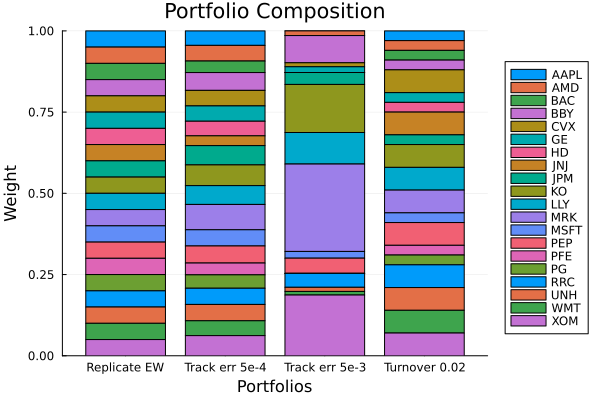

In [7]:
results = [res_replicate_ew, track_res[1], track_res[3], turnover_res[2]]
labels = ["Replicate EW", "Track err 5e-4", "Track err 5e-3", "Turnover 0.02"]

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*